This notebook preprocesses the BRATS2024 train dataset for Segmentation learning with 3D-Unet. It combines 3 of the 4 types of MRI images into one object and pairs it with a corresponding mask. Both files were compressed with .npz format

In [1]:
import os
import random
import splitfolders
from tqdm import tqdm
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
#MINMAXSCALER PRODUCED BUGGGED/XEROX LINES DATA SO USING STANDARD....
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import shutil
import time
from dataclasses import dataclass
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def seed_everything(SEED):
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_default_device():
    gpu_available = torch.cuda.is_available()
    return torch.device('cuda' if gpu_available else 'cpu'), gpu_available

In [4]:
scaler = StandardScaler()

DATASET_PATH = '/home/dberl/THESIS/BRAIN_TUMOR_PROJECT/brats2024/training_data1_v2'

def extract_simple_name(folder_path):
    """Extract simplified name from BraTS folder name.
    Example: BraTS-GLI-00020-100 -> 00020-100"""
    folder_name = os.path.basename(folder_path)
    parts = folder_name.split('-')
    if len(parts) >= 4:
        # Take last two parts after splitting by '-'
        return f"{parts[-2]}-{parts[-1]}"
    return folder_name  # fallback to full name if pattern doesn't match

In [5]:
print(len(os.listdir(DATASET_PATH)))

1324


In [10]:
sample_image_t2f = nib.load(os.path.join(DATASET_PATH, "BraTS-GLI-00005-100/BraTS-GLI-00005-100-t2f.nii.gz")).get_fdata()
print("Original max value:", sample_image_t2f.max())

Original max value: 1406.898681640625


In [11]:
sample_image_t2f_flat = sample_image_t2f.reshape(-1, 1)
# Apply scaling
sample_image_flair_scaled = scaler.fit_transform(sample_image_t2f_flat)

# Reshape it back to the original 3D shape
sample_image_flair_scaled = sample_image_flair_scaled.reshape(sample_image_t2f.shape)

print("Scaled max value:", sample_image_flair_scaled.max())
print("Shape of scaled Image: ", sample_image_flair_scaled.shape)


Scaled max value: 7.002801392250883
Shape of scaled Image:  (182, 218, 182)


In [12]:
sample_image_t1n = nib.load(os.path.join(DATASET_PATH, "BraTS-GLI-00006-100/BraTS-GLI-00006-100-t1n.nii.gz")).get_fdata()
sample_image_t1n = scaler.fit_transform(sample_image_t1n.reshape(-1,sample_image_t1n.shape[-1])).reshape(sample_image_t1n.shape)
sample_image_t1c = nib.load(os.path.join(DATASET_PATH, "BraTS-GLI-00006-100/BraTS-GLI-00006-100-t1c.nii.gz")).get_fdata()
sample_image_t1c = scaler.fit_transform(sample_image_t1c.reshape(-1,sample_image_t1c.shape[-1])).reshape(sample_image_t1c.shape)
sample_image_t2w = nib.load(os.path.join(DATASET_PATH, "BraTS-GLI-00006-100/BraTS-GLI-00006-100-t2w.nii.gz")).get_fdata()
sample_image_t2w = scaler.fit_transform(sample_image_t2w.reshape(-1,sample_image_t2w.shape[-1])).reshape(sample_image_t2w.shape)

In [13]:
sample_mask = nib.load(DATASET_PATH + '/BraTS-GLI-00006-100/BraTS-GLI-00006-100-seg.nii.gz').get_fdata()
sample_mask = sample_mask.astype(np.uint8)  #values between 0 and 255

print("Unique class in the mask", np.unique(sample_mask))

# Class 3 doesn't exist in the mask, so we will reassign class 4 to class 3
# sample_mask[sample_mask == 4] =3
# print("Unique class in the mask after reassign: ", np.unique(sample_mask))
print("Shape of mask: ", sample_mask.shape)

Unique class in the mask [0 2 4]
Shape of mask:  (182, 218, 182)


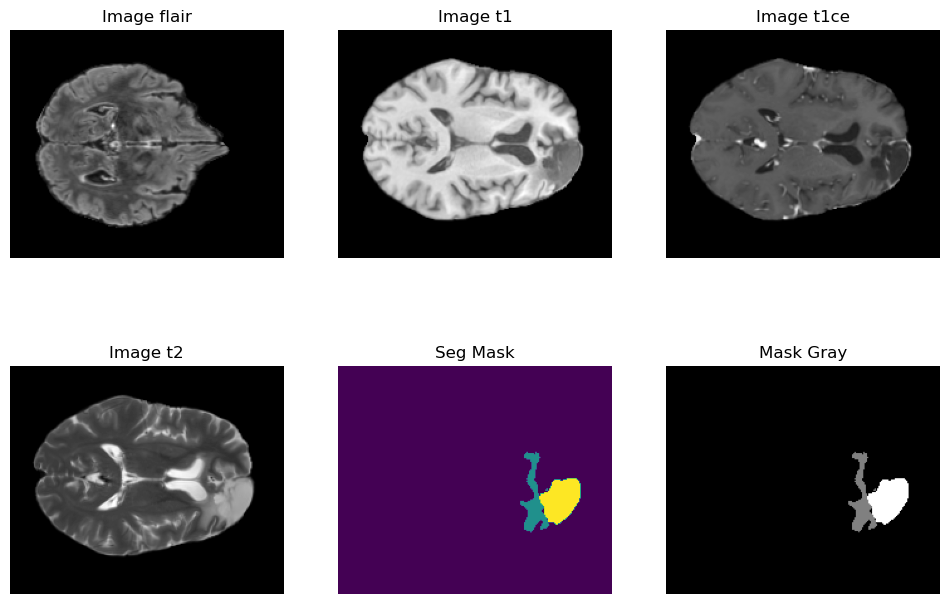

In [16]:
#checking that all images were loaded correctly with middle slice check:

n_slice = 90 # Use consistent slice number (PREVIOUS DATASET WAS MIDDLE AT 70, does this mean something ? yes, that this tumour is far from the center....)

plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(sample_image_flair_scaled[:, :, n_slice], cmap='gray')
plt.title('Image flair')
plt.axis('off')  # Remove axis

plt.subplot(232)
plt.imshow(sample_image_t1n[:, :, n_slice], cmap='gray')
plt.title("Image t1")
plt.axis('off')  # Remove axis

plt.subplot(233)
plt.imshow(sample_image_t1c[:, :, n_slice], cmap='gray')
plt.title("Image t1ce")
plt.axis('off')  # Remove axis

plt.subplot(234)
plt.imshow(sample_image_t2w[:, :, n_slice], cmap='gray')
plt.title("Image t2")
plt.axis('off')  # Remove axis

plt.subplot(235)
plt.imshow(sample_mask[:, :, n_slice])
plt.title("Seg Mask")
plt.axis('off')  # Remove axis

plt.subplot(236)
plt.imshow(sample_mask[:, :, n_slice], cmap='gray')
plt.title('Mask Gray')
plt.axis('off')  # Remove axis

# Save without padding and axes
plt.savefig("gt_plot.png", bbox_inches='tight', pad_inches=0)
plt.show()

In [17]:
#now comes the idea of combining all images into one multi-channel thing... the author skipped t1n for some reason...( not relevant data)

combined_image = np.stack([sample_image_flair_scaled,sample_image_t1c, sample_image_t2w],axis=3)
print("Shape before cropping: ", combined_image.shape)

Shape before cropping:  (182, 218, 182, 3)


In [18]:
combined_image = combined_image[20:-20,20:-20,20:-20]
sample_mask = sample_mask[20:162,20:198,20:162]
print("Image shape after cropping: ", combined_image.shape)
print("Mask shape after cropping: ", sample_mask.shape)
size_bytes = sample_mask.nbytes
size_mb = size_bytes/(1024**2)
print(size_mb)

Image shape after cropping:  (142, 178, 142, 3)
Mask shape after cropping:  (142, 178, 142)
3.4229202270507812


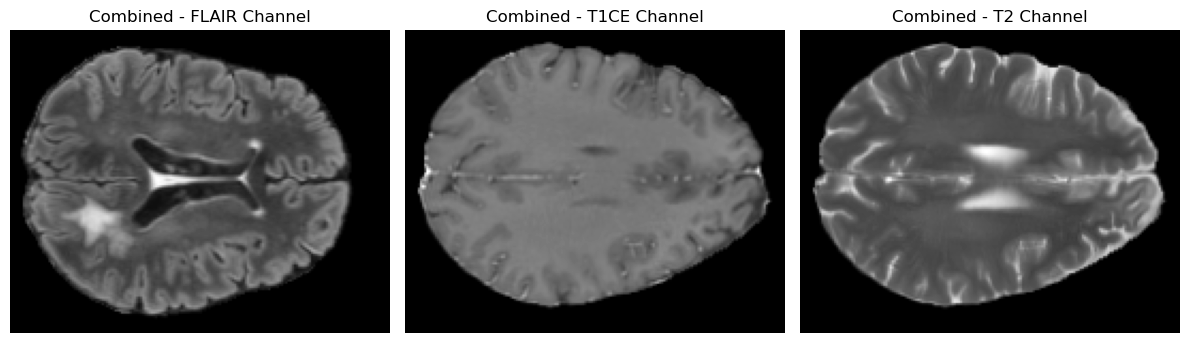

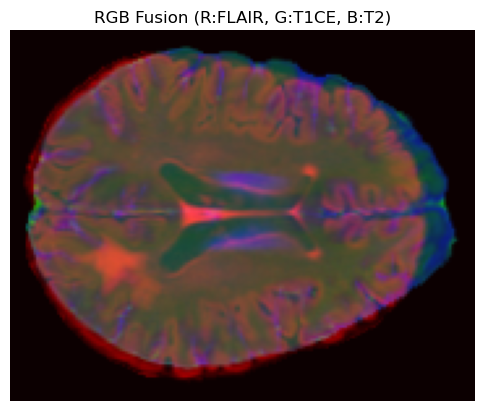

In [19]:
# Visualize combined image
plt.figure(figsize=(12, 4))
combined_x = combined_image
# Show each channel individually
plt.subplot(131)
plt.imshow(combined_x[:, :, n_slice, 0], cmap='gray')
plt.title('Combined - FLAIR Channel')
plt.axis('off')

plt.subplot(132)
plt.imshow(combined_x[:, :, n_slice, 1], cmap='gray')
plt.title('Combined - T1CE Channel')
plt.axis('off')

plt.subplot(133)
plt.imshow(combined_x[:, :, n_slice, 2], cmap='gray')
plt.title('Combined - T2 Channel')
plt.axis('off')

plt.tight_layout()
plt.savefig("combined_channels.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Optional: RGB visualization of 3 channels
plt.figure(figsize=(6, 6))
rgb_combined = np.stack([
    combined_x[:, :, n_slice, 0],  # FLAIR as Red
    combined_x[:, :, n_slice, 1],  # T1CE as Green
    combined_x[:, :, n_slice, 2],  # T2 as Blue
], axis=2)
# Normalize for display
rgb_combined = (rgb_combined - rgb_combined.min()) / (rgb_combined.max() - rgb_combined.min())
plt.imshow(rgb_combined)
plt.title('RGB Fusion (R:FLAIR, G:T1CE, B:T2)')
plt.axis('off')
plt.savefig("rgb_fusion.png", bbox_inches='tight', pad_inches=0)
plt.show()

In [21]:
t1c_list = sorted(glob.glob(f"{DATASET_PATH}/*/*t1c.nii.gz"))
t2w_list = sorted(glob.glob(f"{DATASET_PATH}/*/*t2w.nii.gz"))
t2f_list = sorted(glob.glob(f"{DATASET_PATH}/*/*t2f.nii.gz"))
mask_list = sorted(glob.glob(f"{DATASET_PATH}/*/*seg.nii.gz"))

In [22]:
print("t1c list: ", len(t1c_list))
print("t2w list: ", len(t2w_list))
print("t2f list: ", len(t2f_list))
print("Mask list: ", len(mask_list))

t1c list:  1324
t2w list:  1324
t2f list:  1324
Mask list:  1324


In [23]:
all_t1c = set(os.path.basename(f).replace('-t1c.nii.gz', '') for f in t1c_list)
all_t2w = set(os.path.basename(f).replace('-t2w.nii.gz', '') for f in t2w_list)
all_t2f = set(os.path.basename(f).replace('-t2f.nii.gz', '') for f in t2f_list)

missing_t2w = all_t1c - all_t2w
missing_t2f = all_t1c - all_t2f

print("Missing T2W files:", missing_t2w)
print("Missing T2F files:", missing_t2f)

Missing T2W files: set()
Missing T2F files: set()


In [24]:
# Create output directory for combined files
os.makedirs("BraTS2024_Preprocessed/input_data_3channels_combined", exist_ok=True)

# Process each set of scans
for idx in tqdm(range(len(t2w_list)), desc="Preparing to stack, crop and save combined", unit="file"):
    # Load and normalize T1C images
    temp_image_t1c = nib.load(t1c_list[idx]).get_fdata()
    temp_image_t1c = scaler.fit_transform(temp_image_t1c.reshape(-1, temp_image_t1c.shape[-1])).reshape(temp_image_t1c.shape)
    
    # Load and normalize T2W images
    temp_image_t2w = nib.load(t2w_list[idx]).get_fdata()
    temp_image_t2w = scaler.fit_transform(temp_image_t2w.reshape(-1, temp_image_t2w.shape[-1])).reshape(temp_image_t2w.shape)
    
    # Load and normalize T2F images (FLAIR equivalent)
    temp_image_t2f = nib.load(t2f_list[idx]).get_fdata()
    temp_image_t2f = scaler.fit_transform(temp_image_t2f.reshape(-1, temp_image_t2f.shape[-1])).reshape(temp_image_t2f.shape)
    
    # Load mask
    temp_mask = nib.load(mask_list[idx]).get_fdata()
    
    # Stack the images (channels last)
    temp_combined_images = np.stack([temp_image_t2f, temp_image_t1c, temp_image_t2w], axis=3)
    
    # Crop to region of interest using a simpler 20:-20 approach
    temp_combined_images = temp_combined_images[20:-20, 20:-20, 20:-20]
    temp_mask = temp_mask[20:-20, 20:-20, 20:-20]
    
    # Check dimensions match between image and mask
    if temp_combined_images.shape[:3] != temp_mask.shape:
        print(f"Warning: Dimensions mismatch in scan {idx}")
        print(f"Image shape: {temp_combined_images.shape}, Mask shape: {temp_mask.shape}")
        continue
    
    # Check if the mask contains enough tumor pixels (>1% non-background)
    val, counts = np.unique(temp_mask, return_counts=True)
    
    # If a volume has less than 1% of mask, we simply ignore to reduce computation
    if (1 - (counts[0]/counts.sum())) > 0.01:
        # Extract simplified name from the folder path
        folder_path = os.path.dirname(t1c_list[idx])
        simple_name = extract_simple_name(folder_path)
        
        # Save both image and mask in the same .npz file
        combined_filename = f"BraTS2024_Preprocessed/input_data_3channels_combined/{simple_name}.npz"
        
        # Save with compression - both image and mask in same file
        np.savez_compressed(combined_filename, 
                          image=temp_combined_images, 
                          mask=temp_mask.astype(np.uint8))
        
        print(f"Saved combined file: {combined_filename}")
    else:
        print(f"Skipping scan {idx} - less than 1% tumor pixels")

Preparing to stack, crop and save combined:   0%|          | 1/1324 [00:00<18:44,  1.18file/s]

Skipping scan 0 - less than 1% tumor pixels


Preparing to stack, crop and save combined:   0%|          | 2/1324 [00:01<18:09,  1.21file/s]

Skipping scan 1 - less than 1% tumor pixels


Preparing to stack, crop and save combined:   0%|          | 3/1324 [00:03<28:46,  1.31s/file]

...

Saved combined file: BraTS2024_Preprocessed/input_data_3channels_combined/03062-100.npz


Preparing to stack, crop and save combined: 100%|█████████▉| 1323/1324 [36:26<00:01,  1.84s/file]

Saved combined file: BraTS2024_Preprocessed/input_data_3channels_combined/03063-100.npz


Preparing to stack, crop and save combined: 100%|██████████| 1324/1324 [36:28<00:00,  1.65s/file]

Saved combined file: BraTS2024_Preprocessed/input_data_3channels_combined/03064-100.npz
